# Run experiments (notebook runner)

Uruchamiamy eksperymenty z `src/experiments` **jeden po jednym** i pokazujemy ich wyniki (stdout/stderr + wykresy) bez zapisywania plików na dysk.

Kolejność (będziemy dodawać kolejne sekcje):
1. `TimeInconsistencyApple.py`
2. `DecisionMAkingShop.py`
3. `two_state_counterexample.py`
4. `two_state_qlearning.py`
5. `InventoryMDP.py`

In [11]:
from __future__ import annotations

import contextlib
import io
import runpy
import sys
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repo root by searching upwards for the `src/` directory."""
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repo root starting from {here}")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("Python:", sys.version.split()[0])


def run_module_inline_no_savefig(module: str) -> str:
    """Run a module (like `python -m ...`) and show plots inline instead of saving PNGs."""
    import matplotlib.pyplot as plt
    from IPython.display import display

    original_savefig = plt.savefig
    buf_out = io.StringIO()
    buf_err = io.StringIO()

    def _patched_savefig(*_args, **_kwargs):
        fig = plt.gcf()
        display(fig)
        plt.close(fig)
        return None

    try:
        plt.savefig = _patched_savefig  # type: ignore[assignment]
        with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
            runpy.run_module(module, run_name="__main__")
    finally:
        plt.savefig = original_savefig  # type: ignore[assignment]
        try:
            plt.close("all")
        except Exception:
            pass

    out = buf_out.getvalue()
    err = buf_err.getvalue()
    out = out + ("\n\n[stderr]\n" + (err.rstrip() if err else "(empty)"))
    return out

REPO_ROOT: /run/media/mwrona/Nowy/Engineering-Thesis
Python: 3.14.2


## 1) `TimeInconsistencyApple.py`

Ten skrypt ma kod w top-level, więc uruchamiamy go jako moduł.
Wykresy są przechwytywane: zamiast `plt.savefig(...)` wyświetlamy je w notebooku.

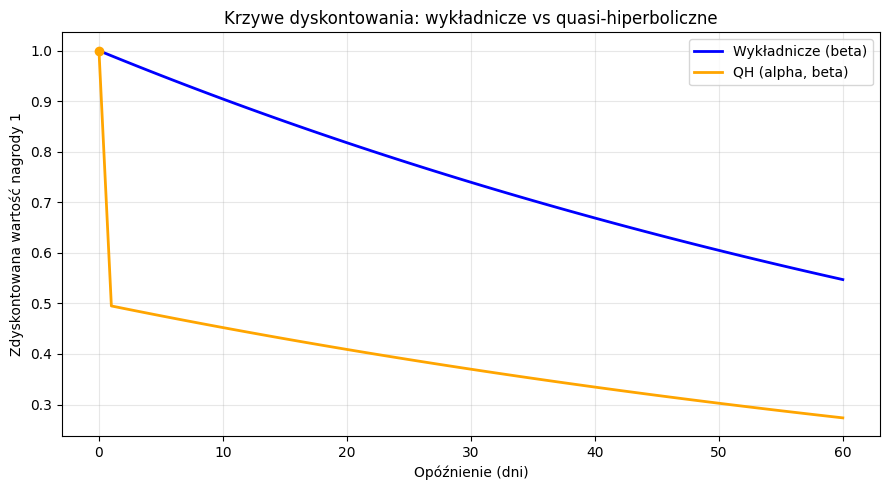

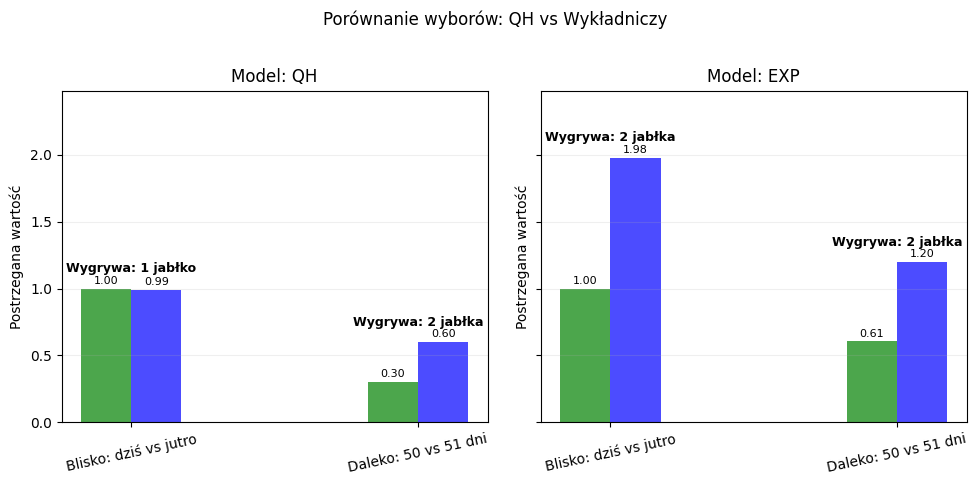

Scenariusz                   | ds  dl  | QH 1j      QH 2j      QH wybór   | EXP 1j     EXP 2j     EXP wybór 
------------------------------------------------------------------------------------------------------------------------
Blisko: dziś vs jutro        | 0   1   | 1.0000     0.9900     1 jabłko   | 1.0000     1.9800     2 jabłka  
Daleko: 50 vs 51 dni         | 50  51  | 0.3025     0.5990     2 jabłka   | 0.6050     1.1979     2 jabłka  



In [10]:
out = run_module_inline_no_savefig("src.experiments.TimeInconsistencyApple")
print(out)

## 2) `DecisionMAkingShop.py`

Skrypt zapisuje wykresy przez `plt.savefig(...)`, ale w notebooku przechwytujemy to i pokazujemy wykresy inline (bez zapisu na dysk).

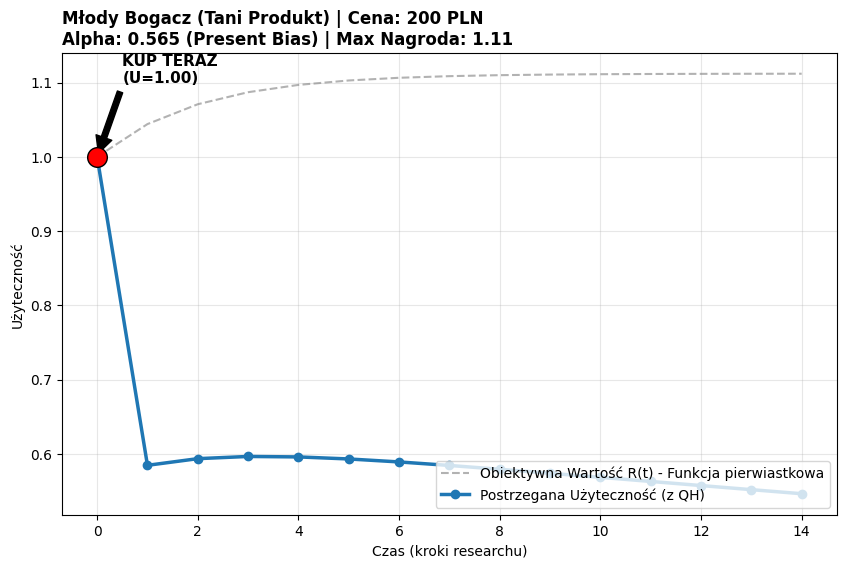

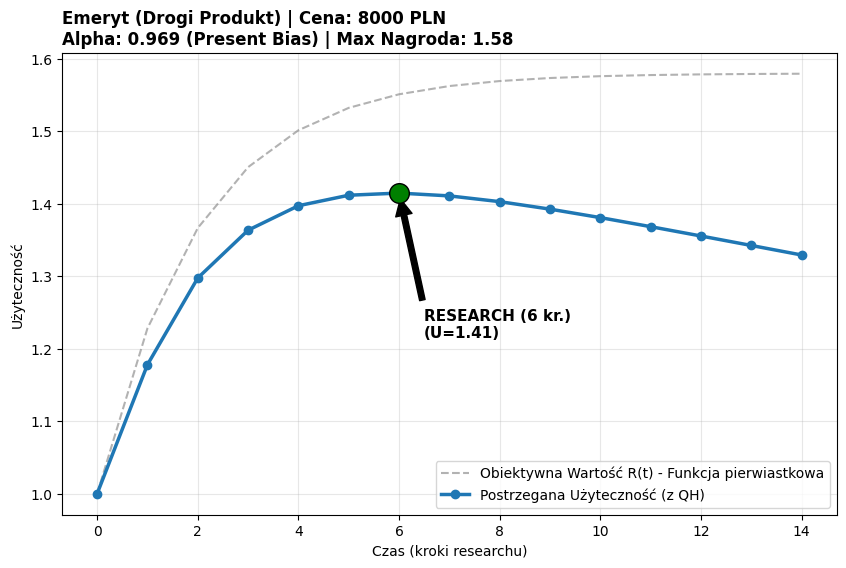

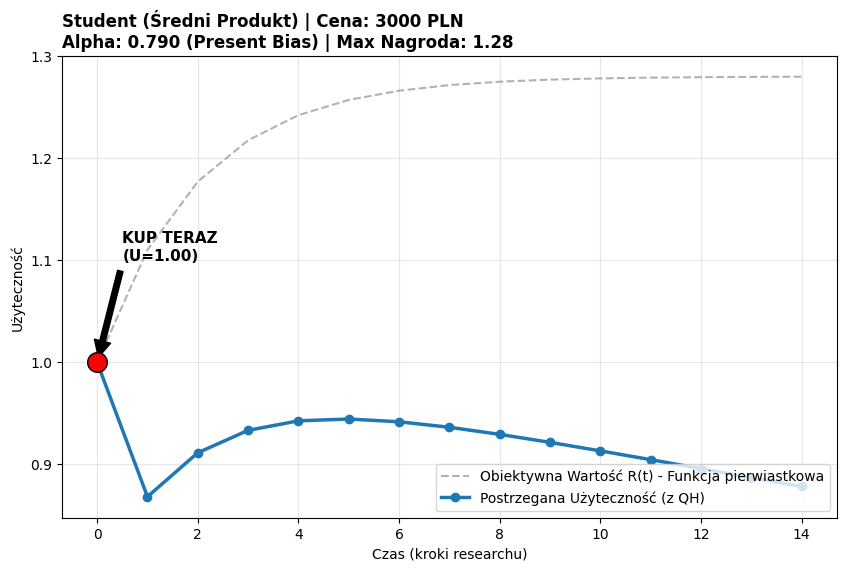

Zapisano wykres do pliku: Decyzja_Młody_Bogacz_Tani_Produkt_Pierwiastek.png
Zapisano wykres do pliku: Decyzja_Emeryt_Drogi_Produkt_Pierwiastek.png
Zapisano wykres do pliku: Decyzja_Student_Średni_Produkt_Pierwiastek.png

--- Zakończono symulację i zapisano wszystkie wykresy z nagrodą pierwiastkową. ---


[stderr]
(empty)


In [12]:
out = run_module_inline_no_savefig("src.experiments.DecisionMAkingShop")
print(out)

## 3) `two_state_counterexample.py`

Uruchomienie 1:1 jak w skrypcie (domyślnie **bardzo długi** bieg: `n_sweeps = 10_000_000` dla 3 polityk).
Wyniki pojawią się jako tabela na stdout.

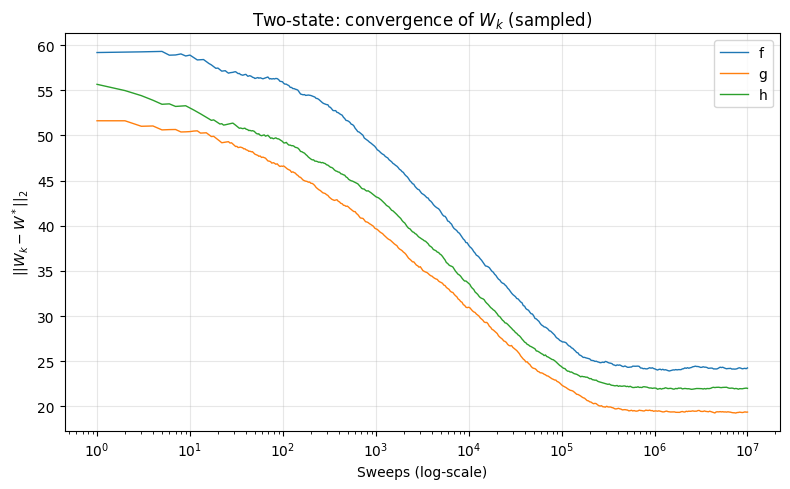

--- Reproducing Table 1c (alpha=0.5, beta=0.8) ---
Pair       | f (Target)   | g (Target)   | h (Target)  
--------------------------------------------------
Policy f [################################] 100.00% (10,000,000/10,000,000) | ETA: 0ss
Policy g [################################] 100.00% (10,000,000/10,000,000) | ETA: 0ss
Policy h [################################] 100.00% (10,000,000/10,000,000) | ETA: 0ss
1, a1      | 18.82   (18.88) | 16.83   (16.83) | 18.03   (18.0)
1, a2      | 18.96   (19.0) | 16.70   (16.77) | 18.02   (18.0)
2, a1      | 32.09   (32.11) | 29.58   (29.56) | 31.00   (31.0)

Legenda: Wartość obliczona (Wartość z artykułu)


[stderr]
(empty)


In [14]:
out = run_module_inline_no_savefig("src.experiments.two_state_counterexample")
print(out)

## 4) `two_state_qlearning.py`

Ten skrypt implementuje QH Q-learning (Alg. 2) dla 2‑stanowego kontrprzykładu.

Uwaga: domyślnie trening ma `steps=300_000`. Poniżej robimy krótszy bieg (quick), żeby dało się to uruchamiać komfortowo w notebooku. Jeśli chcesz pełny bieg 1:1, uruchom komórkę „full run” na końcu sekcji.

In [15]:
from src.experiments.two_state_qlearning import train_agent

# Quick run (adjust steps if needed)
agent = train_agent(steps=50_000)

targets = {
    (0, 0): 18.88,
    (0, 1): 19.00,
    (1, 0): 32.11,
}

print("--- QH Q-learning on two-state MDP (quick run) ---")
print(f"epsilon final: {agent.epsilon:.4f}")
print("Q-table (rows=state, cols=action):")
for s in range(agent.n_states):
    print(f"s={s}: {agent.Q[s, 0]:8.3f} {agent.Q[s, 1]:8.3f}")

print("\nGreedy policy (argmax_a Q):")
print(agent.get_policy())

print("\nComparison to Table 1c targets:")
for (s, a), tgt in targets.items():
    est = agent.Q[s, a]
    print(f"(s={s}, a={a}) -> est={est:7.3f} | target≈{tgt}")

--- QH Q-learning on two-state MDP (quick run) ---
epsilon final: 0.1634
Q-table (rows=state, cols=action):
s=0:   18.827   18.519
s=1:   31.998   31.360

Greedy policy (argmax_a Q):
[0 0]

Comparison to Table 1c targets:
(s=0, a=0) -> est= 18.827 | target≈18.88
(s=0, a=1) -> est= 18.519 | target≈19.0
(s=1, a=0) -> est= 31.998 | target≈32.11


In [17]:
#Full run (1:1 jak w skrypcie) — opcjonalnie:
out = run_module_inline_no_savefig("src.experiments.two_state_qlearning")
print(out)

--- QH Q-learning on two-state MDP (alpha=0.5, beta=0.8) ---
epsilon final: 0.0595
Q-table (rows=state, cols=action):
s=0:   18.887   18.869
s=1:   32.107   31.933

Greedy policy (argmax_a Q):
[0 0]

Comparison to Table 1c targets (f/g/h share same numeric targets per (s,a)):
(s=0, a=0) -> est= 18.887 | target≈18.88
(s=0, a=1) -> est= 18.869 | target≈19.0
(s=1, a=0) -> est= 32.107 | target≈32.11


[stderr]
<frozen runpy>:128: RuntimeWarning: 'src.experiments.two_state_qlearning' found in sys.modules after import of package 'src.experiments', but prior to execution of 'src.experiments.two_state_qlearning'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))


## 4) `InventoryMDP.py`

Uruchomienie 1:1 jak w skrypcie. To jest długie (domyślnie `n_iterations = 5_000_000` i kilka seedów).
W notebooku przechwytujemy `plt.savefig(...)` i pokazujemy wykresy inline (bez zapisu na dysk).

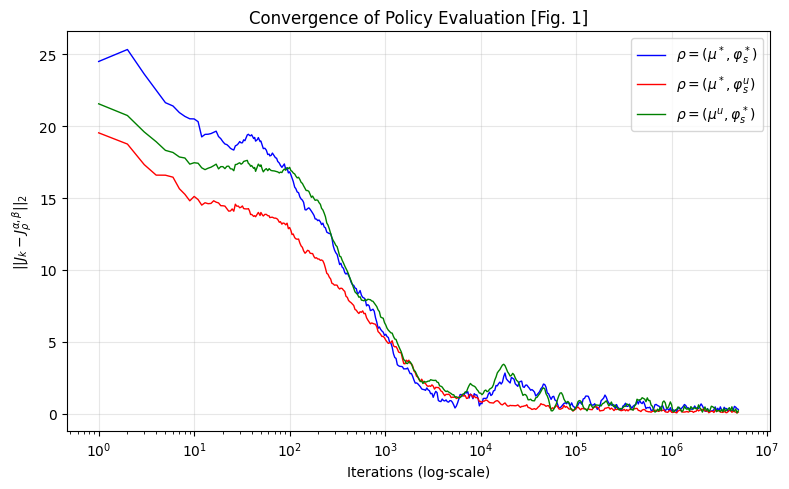


--- Running Optimal Control (High Precision Mode) ---

Optimal deterministic policies (found by exhaustive search):
mu* actions per state: [1, 0, 0]
phi_s* actions per state: [2, 1, 0]

QH Q-Value Function Q*_{mu*,phi_s*} (Profits):
s/a   0        1        2       
------------------------------
0         9.32    11.39    10.56
1        16.39    15.56    10.56
2        20.56    15.56    10.56

--- Running Policy Evaluation (Reproducing Fig 1) ---
Analytical J^{alpha, beta} for $\rho = (\mu^*, \varphi_s^*)$: [11.385 16.385 20.56 ]
Final J estimate for $\rho = (\mu^*, \varphi_s^*)$ (mean±std over 3 seeds): [11.43614535 16.45346643 20.56697366] ± [0.21689058 0.13465213 0.14183312]
Analytical J^{alpha, beta} for $\rho = (\mu^*, \varphi_s^u)$: [ 8.42312932 13.42312932 17.72406713]
Final J estimate for $\rho = (\mu^*, \varphi_s^u)$ (mean±std over 3 seeds): [ 8.42677658 13.41291561 17.67589909] ± [0.08340804 0.03630056 0.0616512 ]
Analytical J^{alpha, beta} for $\rho = (\mu^u, \varphi_s^*)$:

In [18]:
out = run_module_inline_no_savefig("src.experiments.InventoryMDP")
print(out)